In [2]:
import matplotlib.pyplot as plt
import json
import os
import numpy as np
BASE_DIR = '/root/workspace/vllm/examples'
SOLO_DIR = f'{BASE_DIR}/0_solorun_llm_1gpu/'

In [3]:
# 遍历SOLO_DIR下的所有文件，读取json文件，提取数据
def get_data(model_name):
    results = []
    for file in os.listdir(SOLO_DIR):
        if file.endswith('.json'):
            if model_name in file:
                with open(SOLO_DIR + file, 'r') as f:
                    data = json.load(f)
                    # 读取关键词：num_prompts， request_rate， p99_ttft_ms，mean_ttft_ms， p99_tpot_ms， mean_tpot_ms
                    # print(data['num_prompts'], data['request_rate'], data['p99_ttft_ms'], data['mean_ttft_ms'], data['p99_tpot_ms'], data['mean_tpot_ms'])
                    result = [data['num_prompts'], data['request_rate'], data['p99_ttft_ms'], data['mean_ttft_ms'], data['p99_tpot_ms'], data['mean_tpot_ms']]
                    results.append(result)
    return results

In [4]:
# 绘图
def plt_fig(request_rate, model_name):
    data = get_data(model_name)
    fig = plt.figure(figsize=(3, 2.5), dpi=150)
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(model_name)
    ax.set_xlabel('Request Rate')
    ax.set_ylabel('Latency (ms)')
    data = [x for x in data if x[0] == request_rate]
    data.sort(key=lambda x: x[1])
    print(data)
    label_name = ['p99_ttft_ms', 'mean_ttft_ms', 'p99_tpot_ms', 'mean_tpot_ms']
    markers = ['o', '+', 'x', '*']

    for i in range(4):
        ax.plot([x[1] for x in data], [x[i+2] for x in data], label=label_name[i], marker=markers[i], color=plt.cm.viridis(i/4))
    plt.xticks([x[1] for x in data])
    ax.legend()
    ax.grid(axis='y', alpha=0.5, linestyle='-.')
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()
model_name = 'opt-6.7b'
request_rates = [50, 100, 150, 200]
# for request_rate in request_rates:
#     plt_fig(request_rate, model_name)

In [81]:
def get_throughput(model_names, store_cache_layerss, gpu_utilizations, request_rate):
    
    request_rate = request_rate
    request_num = 200
    preemtion_mode = 'swap'
    input_throughputs, output_throughputs, p99_ttfts, p99_tpots, reqs_throughputs = [], [], [], [], []
    for i in range(len(model_names)):
        input_throughput, output_throughput, p99_ttft, p99_tpot, reqs_throughput = [], [], [], [], []
        for j in range(len(store_cache_layerss)): 
            input_tgt, output_tgt, p99_ttft_, p99_tpot_, reqs_tgt = [], [], [], [], []
            if model_names[i] == 'meta-llama_Llama-2-70b-hf':
                file_path = f'{BASE_DIR}/logs/swap_recompute/{model_names[i]}_client_{gpu_utilizations[i]}_{request_rate}_{request_num}_{preemtion_mode}_{store_cache_layerss[j]}_4gpu.log'
            else:    
                file_path = f'{BASE_DIR}/logs/swap_recompute/{model_names[i]}_client_{gpu_utilizations[i]}_{request_rate}_{request_num}_{preemtion_mode}_{store_cache_layerss[j]}_2gpu.log'
            with open(file_path, 'r') as file:
                lines = file.readlines()
                for line in lines:
                    if 'Input token throughput' in line:
                        input_tgt.append(float(line.split()[-1]))
                    if 'Output token throughput' in line:
                        output_tgt.append(float(line.split()[-1]))
                    if 'P99 TTFT' in line:
                        p99_ttft_.append(float(line.split()[-1]))
                    if 'Mean TPOT' in line:
                        p99_tpot_.append(float(line.split()[-1]))
                    if 'Request throughput' in line:
                        reqs_tgt.append(float(line.split()[-1])) 
            if store_cache_layerss[j] == 1.0:
                input_throughput.append(np.min(input_tgt))
                output_throughput.append(np.min(output_tgt))
                p99_ttft.append(np.max(p99_ttft_))
                p99_tpot.append(np.max(p99_tpot_))
                reqs_throughput.append(np.min(reqs_tgt))
            else:                  
                input_throughput.append(np.max(input_tgt))
                output_throughput.append(np.max(output_tgt))
                p99_ttft.append(np.min(p99_ttft_))
                p99_tpot.append(np.min(p99_tpot_))
                reqs_throughput.append(np.max(reqs_tgt))
            # input_throughput.append(np.mean(input_tgt))
            # output_throughput.append(np.mean(output_tgt))
            # p99_ttft.append(np.mean(p99_ttft_))
            # p99_tpot.append(np.mean(p99_tpot_))
            # reqs_throughput.append(np.mean(reqs_tgt))    
        input_throughputs.append(input_throughput)
        output_throughputs.append(output_throughput)
        p99_ttfts.append(p99_ttft)
        p99_tpots.append(p99_tpot)
        reqs_throughputs.append(reqs_throughput)

    print(input_throughputs, output_throughputs, p99_ttfts, p99_tpots, reqs_throughputs)    
    return input_throughputs, output_throughputs, p99_ttfts, p99_tpots, reqs_throughputs        

[[287.69, 317.54, 291.27, 288.17, 285.72, 280.68, 280.8, 283.73, 278.76, 273.76]] [[266.83, 234.56, 258.29, 281.72, 262.52, 274.51, 271.88, 277.36, 267.13, 261.59]] [[5884.52, 5682.34, 5474.01, 10497.36, 3482.43, 6295.63, 5807.83, 7042.69, 9574.61, 9300.11]] [[154.28, 148.7, 149.29, 163.72, 155.18, 240.44, 148.15, 147.49, 158.08, 172.92]] [[1.16, 1.28, 1.18, 1.16, 1.15, 1.13, 1.13, 1.15, 1.13, 1.11]]
output_throughputs_improvement: [2.0031346764020066, -10.332963798310324, -1.2615161130012442, 7.695248289307716, 0.3555181773003581, 4.939026721204946, 3.9336366069039417, 6.028517909706044, 2.117817959402126, 0.0]
max output_throughputs_improvement: 7.695248289307716
reqs_throughputs_improvement: [4.504504504504489, 15.315315315315308, 6.306306306306292, 4.504504504504489, 3.6036036036035863, 1.8018018018017834, 1.8018018018017834, 3.6036036036035863, 1.8018018018017834, 0.0]
max reqs_throughputs_improvement: 15.315315315315308
p99_ttfts_improvement: [36.726339795980905, 38.9002925771845

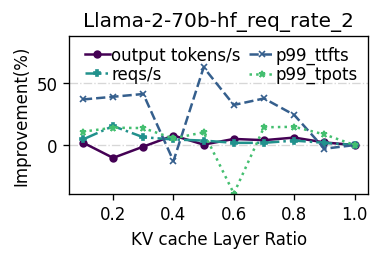

mean_output_throughputs: [1.5478420428915567]
mean_reqs_throughputs: [4.32432432432431]
[[370.38, 420.11, 375.72, 361.48, 366.08, 358.3, 357.75, 355.84, 359.68, 342.51]] [[347.77, 303.27, 327.55, 355.88, 347.58, 358.92, 340.17, 346.66, 343.98, 327.28]] [[5820.58, 7155.01, 8181.09, 4790.97, 8837.79, 6981.98, 10204.04, 7619.34, 5145.73, 20931.87]] [[282.86, 260.79, 218.53, 264.18, 333.16, 333.31, 253.8, 267.28, 261.35, 395.08]] [[1.5, 1.7, 1.52, 1.46, 1.48, 1.45, 1.45, 1.44, 1.45, 1.38]]
output_throughputs_improvement: [6.2606942067954074, -7.336225861647517, 0.08249816670741833, 8.738694695673436, 6.202639941334641, 9.667562943045724, 3.9385235883647165, 5.921535076998306, 5.102664385235898, 0.0]
max output_throughputs_improvement: 9.667562943045724
reqs_throughputs_improvement: [8.695652173913052, 23.188405797101456, 10.144927536231894, 5.797101449275368, 7.24637681159421, 5.072463768115947, 5.072463768115947, 4.347826086956526, 5.072463768115947, 0.0]
max reqs_throughputs_improvement:

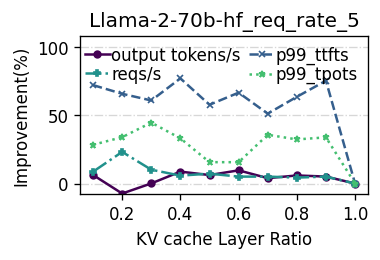

mean_output_throughputs: [3.8578587142508036]
mean_reqs_throughputs: [7.4637681159420355]
[[403.08, 436.53, 401.78, 393.16, 389.48, 379.64, 383.78, 376.83, 384.01, 374.37]] [[361.17, 299.51, 344.87, 386.86, 372.34, 380.63, 367.21, 372.71, 364.48, 357.72]] [[7823.36, 11830.75, 7586.85, 7783.55, 8186.45, 8007.23, 9370.33, 7966.53, 8179.83, 12125.88]] [[286.17, 417.03, 370.64, 373.46, 544.62, 508.29, 693.48, 652.06, 545.91, 604.96]] [[1.63, 1.76, 1.62, 1.59, 1.57, 1.53, 1.55, 1.52, 1.55, 1.51]]
output_throughputs_improvement: [0.9644414625964409, -16.272503634127258, -3.5921950128592255, 8.146036005814599, 4.086995415408685, 6.404450408140436, 2.652912892765278, 4.190428267919029, 1.8897461701889722, 0.0]
max output_throughputs_improvement: 8.146036005814599
reqs_throughputs_improvement: [7.947019867549661, 16.55629139072848, 7.284768211920537, 5.298013245033117, 3.973509933774838, 1.3245033112582794, 2.6490066225165587, 0.6622516556291397, 2.6490066225165587, 0.0]
max reqs_throughputs_im

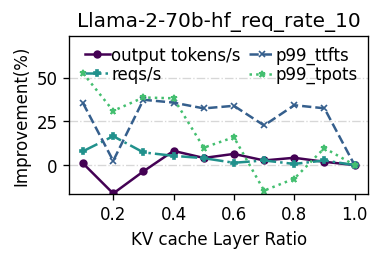

mean_output_throughputs: [0.8470311975846958]
mean_reqs_throughputs: [4.834437086092716]
[[401.03, 441.63, 407.65, 381.25, 384.73, 377.69, 384.38, 375.93, 385.32, 371.44]] [[361.17, 303.23, 348.78, 380.37, 363.58, 374.3, 365.09, 370.23, 367.25, 353.64]] [[12083.42, 11853.62, 13740.7, 11997.69, 17687.64, 13685.15, 15494.2, 13118.73, 12573.24, 19257.24]] [[465.67, 376.31, 495.31, 461.07, 531.35, 522.86, 580.78, 670.03, 403.12, 694.54]] [[1.62, 1.78, 1.65, 1.54, 1.55, 1.53, 1.55, 1.52, 1.56, 1.5]]
output_throughputs_improvement: [2.1292840176450714, -14.254609207103261, -1.3742789277231122, 7.5585341024771004, 2.81076801266825, 5.842099310032809, 3.237755909964933, 4.691211401425187, 3.848546544508544, 0.0]
max output_throughputs_improvement: 7.5585341024771004
reqs_throughputs_improvement: [8.000000000000007, 18.666666666666668, 9.999999999999993, 2.6666666666666687, 3.333333333333336, 2.0000000000000018, 3.333333333333336, 1.3333333333333344, 4.0000000000000036, 0.0]
max reqs_throughput

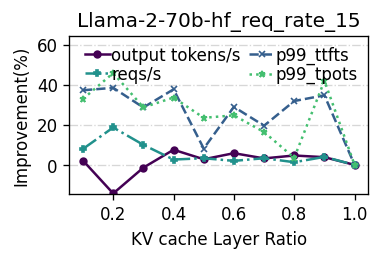

mean_output_throughputs: [1.4489311163895522]
mean_reqs_throughputs: [5.333333333333334]
[[405.75, 449.4, 409.73, 390.3, 398.45, 362.47, 382.19, 371.03, 374.67, 359.74]] [[372.73, 309.48, 351.19, 381.75, 375.59, 363.29, 361.89, 366.57, 356.83, 341.54]] [[16764.06, 15541.03, 14117.83, 15802.61, 15331.58, 26690.83, 17532.2, 19547.54, 20740.56, 25521.65]] [[383.85, 538.62, 491.13, 465.06, 643.99, 476.96, 714.92, 693.89, 422.34, 571.91]] [[1.64, 1.82, 1.66, 1.58, 1.61, 1.46, 1.54, 1.5, 1.51, 1.45]]
output_throughputs_improvement: [9.132166071324002, -9.386894653627687, 2.8254377232534917, 11.773145166012759, 9.969549686713108, 6.368214557592082, 5.958306494114881, 7.328570592024351, 4.476781636118745, 0.0]
max output_throughputs_improvement: 11.773145166012759
reqs_throughputs_improvement: [13.103448275862064, 25.517241379310352, 14.482758620689653, 8.965517241379318, 11.0344827586207, 0.6896551724137937, 6.206896551724143, 3.448275862068969, 4.1379310344827624, 0.0]
max reqs_throughputs_i

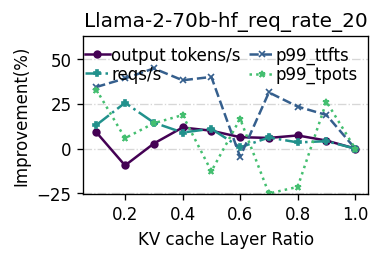

mean_output_throughputs: [4.844527727352573]
mean_reqs_throughputs: [8.758620689655174]


In [82]:
# model_names = ['meta-llama_Llama-2-7b-hf']
# model_names = ['facebook_opt-2.7b', 'facebook_opt-30b', 'meta-llama_Llama-2-7b-hf', 'meta-llama_Llama-2-13b-hf']
model_names = ['facebook_opt-2.7b', 'facebook_opt-30b', 'meta-llama_Llama-2-7b-hf', 'meta-llama_Llama-2-13b-hf', 'meta-llama_Llama-2-70b-hf']
model_names = ['meta-llama_Llama-2-70b-hf']
# gpu_utilizations = [0.1, 0.9, 0.2, 0.4] # 1GPU
# gpu_utilizations = [0.1, 0.5, 0.2, 0.4, 0.5] # 2GPU
gpu_utilizations = [0.9] # 2GPU
store_cache_layerss = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
request_rates = [2, 5, 10, 15, 20]
for request_rate in request_rates:
    input_throughputs, output_throughputs, p99_ttfts, p99_tpots, reqs_throughputs = get_throughput(model_names, store_cache_layerss, gpu_utilizations, request_rate)
    # print(f'input_throughputs: {input_throughputs}')
    # print(f'output_throughputs: {output_throughputs}')
    # print(f'p99_ttfts: {p99_ttfts}')
    # print(f'p99_tpots: {p99_tpots}')
    # print(f'reqs_throughputs: {reqs_throughputs}')
    mean_output_throughputs, mean_reqs_throughputs, mean_p99_ttfts, mean_p99_tpots = [], [], [], []
    for j in range(len(model_names)):
        fig = plt.figure(figsize=(3, 2), dpi=120)
        ax1 = fig.add_subplot(1, 1, 1)
        ax1.set_title('Output Throughput')
        ax1.set_xlabel('KV cache Layer Ratio')
        ax1.set_ylabel('Improvement(%)')
        ax1.spines['right'].set_visible(False)
        ax1.spines['top'].set_visible(False)
        output_throughputs_improvement = [(output_throughputs[j][i] - output_throughputs[j][-1])/output_throughputs[j][-1]*100 for i in range(len(output_throughputs[j]))]
        print(f'output_throughputs_improvement: {output_throughputs_improvement}')
        print(f'max output_throughputs_improvement: {np.max(output_throughputs_improvement)}')
        mean_output_throughputs.append(np.mean(output_throughputs_improvement))
        reqs_throughputs_improvement = [(reqs_throughputs[j][i] - reqs_throughputs[j][-1])/reqs_throughputs[j][-1]*100 for i in range(len(reqs_throughputs[j]))]
        print(f'reqs_throughputs_improvement: {reqs_throughputs_improvement}')
        print(f'max reqs_throughputs_improvement: {np.max(reqs_throughputs_improvement)}')
        mean_reqs_throughputs.append(np.mean(reqs_throughputs_improvement))
        p99_ttfts_improvement = [(p99_ttfts[j][-1]-p99_ttfts[j][i])/p99_ttfts[j][-1]*100 for i in range(len(p99_ttfts[j]))]
        print(f'p99_ttfts_improvement: {p99_ttfts_improvement}')
        print(f'max p99_ttfts_improvement: {np.max(p99_ttfts_improvement)}')
        p99_tpots_improvement = [(p99_tpots[j][-1]-p99_tpots[j][i])/p99_tpots[j][-1]*100 for i in range(len(p99_tpots[j]))]
        print(f'p99_tpots_improvement: {p99_tpots_improvement}')
        print(f'max p99_tpots_improvement: {np.max(p99_tpots_improvement)}')
        
        ax1.plot(store_cache_layerss, output_throughputs_improvement, marker='o', markersize=4, label='output tokens/s', color=plt.cm.viridis(0))
        ax1.plot(store_cache_layerss, reqs_throughputs_improvement, marker='P', markersize=4, label='reqs/s', linestyle='-.', color=plt.cm.viridis(0.5))
        ax1.plot(store_cache_layerss, p99_ttfts_improvement, marker='x', markersize=4, label='p99_ttfts', linestyle='--', color=plt.cm.viridis(0.3))
        ax1.plot(store_cache_layerss, p99_tpots_improvement, marker='*', markersize=4, label='p99_tpots', linestyle=':', color=plt.cm.viridis(0.7))

        ax1.legend(loc='best', ncol=2, handlelength=1.5, labelspacing=0.05, columnspacing=0.5, fontsize=10, borderpad=0.1, handletextpad=0.1, frameon=False)
        plt.title(f'{(model_names[j].split("_")[-1])}_req_rate_{request_rate}')
        ax1.grid(axis='y', alpha=0.5, linestyle='-.')
        ax1.set_ylim(min(min(output_throughputs_improvement), min(reqs_throughputs_improvement), min(p99_tpots_improvement), min(p99_ttfts_improvement)) - 0.1, max(max(output_throughputs_improvement), max(reqs_throughputs_improvement), max(p99_ttfts_improvement), max(p99_tpots_improvement)) * 1.4)
        # ax1.set_ylim(min(min(output_throughputs_improvement), min(reqs_throughputs_improvement)) - 0.1, max(max(output_throughputs_improvement), max(reqs_throughputs_improvement)) * 1.1)
        plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
        plt.show()
        plt.close()
    print(f'mean_output_throughputs: {mean_output_throughputs}')
    print(f'mean_reqs_throughputs: {mean_reqs_throughputs}')    